# Fine-tuning a pretrained transformer

### Pretraining a model from nothing, then measuring exactly what the pretraining was worth

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How masked language modelling turns unlabelled text into a training signal, what a pretrained checkpoint actually contains, how fine-tuning compares against a frozen feature extractor and against the same architecture from random weights across a sweep of labelled-data sizes, how much of the pretraining objective fine-tuning destroys, and whether discriminative learning rates fix it |
| **You should already know** | [The Transformer, built from scratch](../07-the-transformer/). [Transfer learning](../../08-computer-vision/05-transfer-learning/) runs the same three-way comparison on images |
| **Datasets** | A synthetic language defined in this notebook. Nothing is downloaded and no pretrained weights are used |
| **Runtime** | Three to four minutes on a laptop CPU |
| **Next** | [09-09 Time series forecasting](../09-time-series-forecasting/) |

---

## 1. Why this notebook pretrains its own model

The usual version of this chapter downloads BERT, replaces the last layer, calls
`.fit()`, and reports a number. That version teaches you an API. It cannot teach
you what fine-tuning does, because the thing being fine-tuned arrived as several
hundred megabytes of weights nobody in the room has looked at.

So this notebook does the whole cycle from nothing. It defines a small language,
generates a corpus in it, pretrains a transformer on that corpus with a
self-supervised objective, and only then fine-tunes the resulting checkpoint on
a labelled task. Every weight in the pretrained model came from a training run
you can read on this page.

The honest trade is that a synthetic language is not English. What it does have
is the property that makes pretraining work at all: structure that is visible in
unlabelled text and useful for a labelled task nobody mentioned during
pretraining. That is the mechanism. The mechanism is what generalises, and a
corpus small enough to print is the only way to see it.

The plan:

1. Define a language with hidden structure, and generate a corpus
2. Pretrain by masking tokens and predicting them, using no labels at all
3. Fine-tune on a labelled task that needs the hidden structure
4. Compare against a frozen feature extractor and against random initialisation,
   swept over how much labelled data is available
5. Measure how much of the pretraining objective survives fine-tuning

In [1]:
import sys
import math
import copy
import time
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)

print(f"torch {torch.__version__}")

torch 2.11.0+cu128


## 2. A language with something worth learning

Three domains: a harbour, a kitchen, an observatory. Each has eight nouns, eight
adjectives and four verbs of its own. Every sentence follows one template:

> the ADJ NOUN VERB a ADJ NOUN PREP PLACE

The subject noun and the object noun are drawn from independently chosen
domains, so a sentence can mix a harbour subject with a kitchen object. What
holds the language together is agreement that is strong but not absolute:

- an adjective usually comes from the domain of the noun it modifies
- a verb usually comes from the domain of the subject noun
- places and function words belong to no domain

Nothing in the corpus is labelled with a domain. The word "harbour" never
appears. A model that learns which words go together has to work the grouping
out from co-occurrence alone, which is precisely what masked language modelling
rewards.

In [2]:
DOMAINS = ["harbour", "kitchen", "observatory"]
NOUNS = [
    ["barge", "jetty", "anchor", "crane", "buoy", "hull", "dock", "mast"],
    ["skillet", "kettle", "larder", "whisk", "ladle", "oven", "platter", "sieve"],
    ["mirror", "dome", "filter", "tripod", "lens", "chart", "prism", "shutter"],
]
ADJECTIVES = [
    ["salted", "tidal", "weathered", "rusted", "moored", "briny", "drifting", "coastal"],
    ["scalded", "floured", "simmering", "chipped", "buttered", "warmed", "scoured", "blackened"],
    ["polished", "aligned", "dimmed", "calibrated", "silvered", "tilted", "shuttered", "faint"],
]
VERBS = [
    ["hauls", "moors", "tows", "unloads"],
    ["warms", "folds", "scours", "plates"],
    ["tracks", "focuses", "logs", "sweeps"],
]
PLACES = ["quay", "corridor", "terrace", "cellar", "gallery", "annex", "landing", "courtyard"]
FUNCTION = ["the", "a", "near", "beyond"]

WORDS = ([w for group in NOUNS for w in group]
         + [w for group in ADJECTIVES for w in group]
         + [w for group in VERBS for w in group]
         + PLACES + FUNCTION)
ID = {w: i for i, w in enumerate(WORDS)}
MASK_ID = len(WORDS)
VOCAB = MASK_ID + 1
SEQ_LEN = 9

AGREE_ADJ, AGREE_VERB = 0.85, 0.80
NOUN_DOMAIN = {ID[w]: d for d, group in enumerate(NOUNS) for w in group}
SLOT_NAMES = ["the", "adj 1", "noun 1", "verb", "a", "adj 2", "noun 2", "prep", "place"]

print(f"{len(WORDS)} words plus one [MASK] token, so a vocabulary of {VOCAB}")
print(f"per domain: {len(NOUNS[0])} nouns, {len(ADJECTIVES[0])} adjectives, "
      f"{len(VERBS[0])} verbs")
print(f"shared across domains: {len(PLACES)} places and {len(FUNCTION)} function words")


def make_sentence(rng, d_subject, d_object):
    """One sentence as token ids, following the single template."""
    def adjective(domain):
        source = domain if rng.random() < AGREE_ADJ else int(rng.integers(len(DOMAINS)))
        return ID[ADJECTIVES[source][rng.integers(len(ADJECTIVES[source]))]]

    verb_domain = d_subject if rng.random() < AGREE_VERB else int(rng.integers(len(DOMAINS)))
    return [
        ID["the"],
        adjective(d_subject),
        ID[NOUNS[d_subject][rng.integers(len(NOUNS[d_subject]))]],
        ID[VERBS[verb_domain][rng.integers(len(VERBS[verb_domain]))]],
        ID["a"],
        adjective(d_object),
        ID[NOUNS[d_object][rng.integers(len(NOUNS[d_object]))]],
        ID[FUNCTION[2 + int(rng.integers(2))]],
        ID[PLACES[rng.integers(len(PLACES))]],
    ]


def make_corpus(n, rng, balanced=False):
    """Returns token ids (n, 9), the same-domain label, and the subject domain."""
    rows, labels, subjects = [], [], []
    for _ in range(n):
        if balanced:
            d1 = int(rng.integers(len(DOMAINS)))
            d2 = d1 if rng.random() < 0.5 else int((d1 + 1 + rng.integers(len(DOMAINS) - 1))
                                                   % len(DOMAINS))
        else:
            d1, d2 = int(rng.integers(len(DOMAINS))), int(rng.integers(len(DOMAINS)))
        rows.append(make_sentence(rng, d1, d2))
        labels.append(int(d1 == d2))
        subjects.append(d1)
    return (np.array(rows, dtype=np.int64), np.array(labels, dtype=np.int64),
            np.array(subjects, dtype=np.int64))


corpus_rng = np.random.default_rng(SEED)
pretrain_X, _, _ = make_corpus(24_000, corpus_rng)

print(f"\npretraining corpus: {pretrain_X.shape[0]:,} sentences of {SEQ_LEN} tokens, "
      f"{pretrain_X.size:,} tokens in all")
print("three of them:")
for row in pretrain_X[:3]:
    print("  " + " ".join(WORDS[t] for t in row))

72 words plus one [MASK] token, so a vocabulary of 73
per domain: 8 nouns, 8 adjectives, 4 verbs
shared across domains: 8 places and 4 function words



pretraining corpus: 24,000 sentences of 9 tokens, 216,000 tokens in all
three of them:
  the polished mirror tracks a silvered ladle beyond annex
  the scoured whisk unloads a scoured oven beyond corridor
  the rusted crane moors a polished mirror beyond gallery


In [3]:
# What the model has to discover, counted from the corpus rather than asserted.
adj_group = np.full(len(WORDS), -1)
for d, group in enumerate(ADJECTIVES):
    for w in group:
        adj_group[ID[w]] = d
verb_group = np.full(len(WORDS), -1)
for d, group in enumerate(VERBS):
    for w in group:
        verb_group[ID[w]] = d

subject_domain = np.array([NOUN_DOMAIN[t] for t in pretrain_X[:, 2]])
adj_by_domain = np.zeros((len(DOMAINS), len(DOMAINS)))
verb_by_domain = np.zeros((len(DOMAINS), len(DOMAINS)))
for d in range(len(DOMAINS)):
    rows = subject_domain == d
    adj_by_domain[d] = np.bincount(adj_group[pretrain_X[rows, 1]], minlength=len(DOMAINS))
    verb_by_domain[d] = np.bincount(verb_group[pretrain_X[rows, 3]], minlength=len(DOMAINS))
adj_by_domain /= adj_by_domain.sum(axis=1, keepdims=True)
verb_by_domain /= verb_by_domain.sum(axis=1, keepdims=True)

# How uncertain each slot is, from the corpus itself. This is the ceiling on how
# well any masked-token predictor can ever do.
slot_entropy, slot_best = [], []
for j in range(SEQ_LEN):
    counts = np.bincount(pretrain_X[:, j], minlength=VOCAB) / len(pretrain_X)
    nonzero = counts[counts > 0]
    slot_entropy.append(float(-(nonzero * np.log(nonzero)).sum()))
    slot_best.append(float(counts.max()))

slots = pd.DataFrame({"slot": SLOT_NAMES, "entropy (nats)": slot_entropy,
                      "most frequent token's share": slot_best})
print(slots.to_string(index=False, float_format="{:.4f}".format))
print(f"\nguessing the most frequent token would be right {np.mean(slot_best):.4f} of "
      f"the time, averaged over all {SEQ_LEN} slots including the two fixed ones")
print("that is not the baseline the model is scored against; section 3 computes "
      "the one that is")

  slot  entropy (nats)  most frequent token's share
   the         -0.0000                       1.0000
 adj 1          3.1777                       0.0442
noun 1          3.1777                       0.0438
  verb          2.4848                       0.0860
     a         -0.0000                       1.0000
 adj 2          3.1778                       0.0429
noun 2          3.1773                       0.0445
  prep          0.6931                       0.5023
 place          2.0793                       0.1283

guessing the most frequent token would be right 0.3213 of the time, averaged over all 9 slots including the two fixed ones
that is not the baseline the model is scored against; section 3 computes the one that is


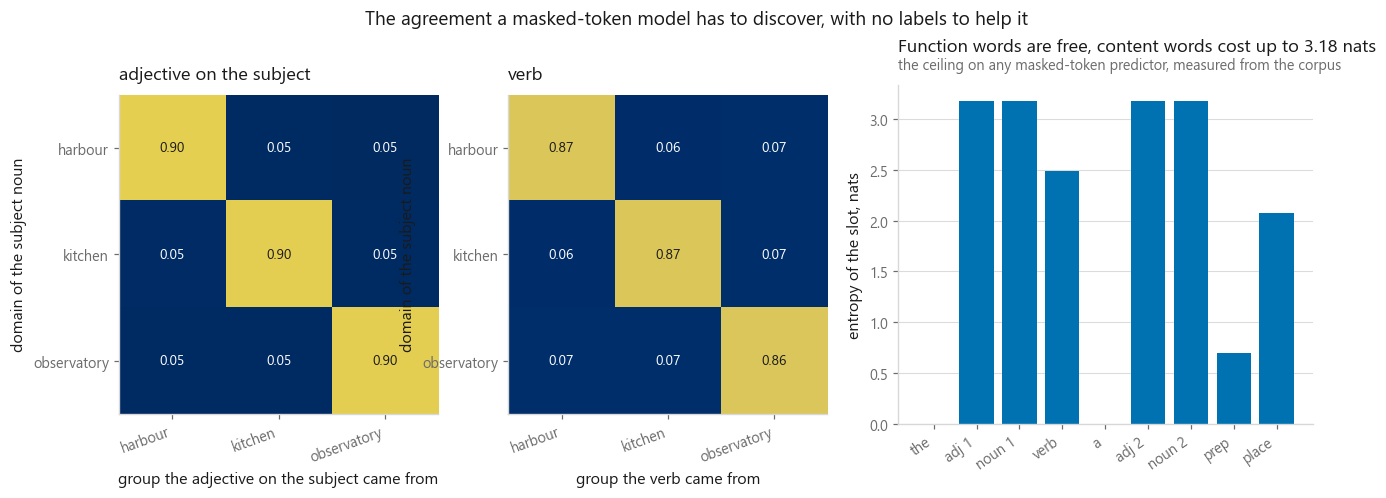

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.0),
                         gridspec_kw={"width_ratios": [1, 1, 1.3]})

for ax, matrix, name in [(axes[0], adj_by_domain, "adjective on the subject"),
                         (axes[1], verb_by_domain, "verb")]:
    im = ax.imshow(matrix, cmap="cividis", vmin=0, vmax=1)
    for i in range(len(DOMAINS)):
        for j in range(len(DOMAINS)):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", fontsize=9,
                    color="white" if matrix[i, j] < 0.55 else style.INK)
    ax.set_xticks(range(len(DOMAINS)), DOMAINS, rotation=20, ha="right")
    ax.set_yticks(range(len(DOMAINS)), DOMAINS)
    ax.set_xlabel(f"group the {name} came from")
    ax.set_ylabel("domain of the subject noun")
    ax.grid(False)
    style.title(ax, name)

axes[2].bar(np.arange(SEQ_LEN), slot_entropy, color=style.PALETTE[0])
axes[2].set_xticks(np.arange(SEQ_LEN), SLOT_NAMES, rotation=35, ha="right")
axes[2].set_ylabel("entropy of the slot, nats")
style.title(axes[2],
            f"Function words are free, content words cost up to "
            f"{max(slot_entropy):.2f} nats",
            "the ceiling on any masked-token predictor, measured from the corpus")

fig.suptitle("The agreement a masked-token model has to discover, with no labels to help it",
             x=0.5, y=1.05, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-the-language.png")

The two heatmaps are the structure, counted from the corpus rather than taken
from the generator. The diagonals are not one, so the agreement is a tendency
and a model cannot get away with a hard rule.

The entropy panel sets expectations for the next section, and it is the number
people forget to compute before being disappointed by a language model's
accuracy. A slot holding one of eight nouns cannot be predicted better than one
in eight when nothing else in the sentence narrows it down, and no amount of
training changes that.

The frequency number printed under the table is a trap I set for myself, so it
stays in with a warning attached. Averaging the most-frequent-token share over
every slot includes the two slots that hold a function word every single time,
and those two are free. The masked-token objective never scores them that way:
the first position is excluded from masking by construction, and the loss only
ever looks at positions that were actually hidden. The baseline that means
something is the same frequency rule evaluated on exactly those positions,
section 3 computes it, and it is lower. A baseline scored on a different set of
rows from the model is not a baseline, it is a second experiment.

## 3. Pretraining: masked token prediction

The self-supervised trick is to hide part of the input and ask the model to
reconstruct it. Choose a fraction of positions at random, replace them with a
reserved `[MASK]` token, and train the model to name what was there. The label
is the original text, so a corpus with no annotation of any kind becomes a
supervised problem.

Two design points matter and both are usually skipped.

The loss is computed **only at the masked positions**. Unmasked positions have
their answer sitting in the input, so including them would train the model to
copy.

The masking rate trades off. Too little and each sentence teaches almost
nothing per forward pass. Too much and the context needed to reconstruct is gone
as well. BERT's 15% is the number everyone inherited.

BERT also replaces some chosen positions with a random token or leaves them
unchanged, to stop the model from learning that `[MASK]` is the only place
anything interesting happens. That refinement is left out here so the objective
stays readable, and it is the first thing to add if you build on this.

In [5]:
def sinusoidal_encoding(n_positions, d_model):
    pe = torch.zeros(n_positions, d_model)
    position = torch.arange(n_positions).unsqueeze(1).float()
    inv_freq = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * inv_freq)
    pe[:, 1::2] = torch.cos(position * inv_freq)
    return pe


D_MODEL, N_HEADS, N_LAYERS, D_FF = 64, 4, 2, 128


class Encoder(nn.Module):
    """The part that gets pretrained and then reused. No task head inside it."""

    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, D_MODEL)
        self.register_buffer("pe", sinusoidal_encoding(SEQ_LEN, D_MODEL))
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(D_MODEL, N_HEADS, D_FF, dropout=0.0,
                                       activation="relu", batch_first=True,
                                       norm_first=True)
            for _ in range(N_LAYERS)])

    def forward(self, x):
        h = self.embed(x) + self.pe
        for block in self.blocks:
            h = block(h)
        return h


class MaskedLM(nn.Module):
    """Encoder plus a vocabulary-sized output layer, used only for pretraining."""

    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.out = nn.Linear(D_MODEL, VOCAB)

    def forward(self, x):
        return self.out(self.encoder(x))


def apply_mask(tokens, rng, rate=0.15):
    """Replace a fraction of positions with [MASK]. Returns the input and the map."""
    chosen = torch.tensor(rng.random(tokens.shape) < rate)
    # Every sentence starts with "the". Masking it teaches nothing, and leaving a
    # sentence with no masked position at all would give an empty loss.
    chosen[:, 0] = False
    masked = tokens.clone()
    masked[chosen] = MASK_ID
    return masked, chosen


torch.manual_seed(SEED)
encoder = Encoder()
mlm = MaskedLM(encoder)
optimiser = torch.optim.Adam(mlm.parameters(), lr=3e-3)

pretrain_t = torch.tensor(pretrain_X)
mask_rng = np.random.default_rng(SEED + 1)
PRETRAIN_EPOCHS, PRETRAIN_BATCH = 8, 256

history = []
started = time.perf_counter()
for epoch in range(PRETRAIN_EPOCHS):
    mlm.train()
    order = torch.randperm(len(pretrain_t))
    total, count, correct = 0.0, 0, 0
    for i in range(0, len(pretrain_t), PRETRAIN_BATCH):
        batch = pretrain_t[order[i:i + PRETRAIN_BATCH]]
        masked, chosen = apply_mask(batch, mask_rng)
        logits = mlm(masked)[chosen]
        targets = batch[chosen]
        loss = F.cross_entropy(logits, targets)
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
        total += float(loss.detach()) * len(targets)
        count += len(targets)
        correct += int((logits.argmax(-1) == targets).sum())
    history.append({"epoch": epoch + 1, "masked-token loss": total / count,
                    "masked-token accuracy": correct / count})

history = pd.DataFrame(history)
pretrain_seconds = time.perf_counter() - started
print(history.to_string(index=False, float_format="{:.4f}".format))
print(f"\npretrained in {pretrain_seconds:.0f} s on "
      f"{sum(p.numel() for p in encoder.parameters()):,} encoder parameters")

 epoch  masked-token loss  masked-token accuracy
     1             2.6901                 0.2307
     2             1.9752                 0.2780
     3             1.9129                 0.2784
     4             1.8911                 0.2816
     5             1.8734                 0.2873
     6             1.8819                 0.2832
     7             1.8713                 0.2896
     8             1.8802                 0.2830

pretrained in 13 s on 71,616 encoder parameters


In [6]:
# Two baselines, so the accuracy above means something.
score_rng = np.random.default_rng(SEED + 2)
holdout_X, _, _ = make_corpus(4000, corpus_rng)
holdout_t = torch.tensor(holdout_X)

freq_by_slot = np.stack([np.bincount(pretrain_X[:, j], minlength=VOCAB) / len(pretrain_X)
                         for j in range(SEQ_LEN)])
masked_probe, chosen_probe = apply_mask(holdout_t, score_rng)
slot_of = np.tile(np.arange(SEQ_LEN), (len(holdout_t), 1))[chosen_probe.numpy()]
truth = holdout_t[chosen_probe].numpy()

guess_uniform = 1.0 / len(WORDS)
guess_frequency = float((freq_by_slot[slot_of].argmax(axis=1) == truth).mean())
loss_frequency = float(-np.log(np.clip(freq_by_slot[slot_of, truth], 1e-12, None)).mean())

print("every number below is computed on the masked positions only, which is where "
      "the model is scored")
print(f"masked positions scored : {len(truth):,}")
print(f"accuracy, uniform guess over the vocabulary : {guess_uniform:.4f}")
print(f"accuracy, the commonest token for that slot : {guess_frequency:.4f}   "
      f"<- the baseline to beat")
print(f"loss,     the commonest token for that slot : {loss_frequency:.4f} nats")
print(f"accuracy, the pretrained model              : "
      f"{history['masked-token accuracy'].iloc[-1]:.4f}")
print(f"loss,     the pretrained model              : "
      f"{history['masked-token loss'].iloc[-1]:.4f} nats")
print(f"\nmodel minus the frequency baseline, both on masked positions: "
      f"{history['masked-token accuracy'].iloc[-1] - guess_frequency:+.4f} accuracy, "
      f"{history['masked-token loss'].iloc[-1] - loss_frequency:+.4f} nats")

every number below is computed on the masked positions only, which is where the model is scored
masked positions scored : 4,822
accuracy, uniform guess over the vocabulary : 0.0139
accuracy, the commonest token for that slot : 0.2298   <- the baseline to beat
loss,     the commonest token for that slot : 2.2500 nats
accuracy, the pretrained model              : 0.2830
loss,     the pretrained model              : 1.8802 nats

model minus the frequency baseline, both on masked positions: +0.0533 accuracy, -0.3698 nats


The model clears the frequency baseline on both accuracy and loss, and it clears
it by the printed margin. Set it against the all-slots average from section 2
instead and the same model appears to lose, which is the whole reason that
earlier number carries a warning: the two baselines are computed over different
positions, and only one of them is scored the way the model is.

When somebody quotes a model as beating or missing a baseline, the first
question is which rows the baseline was evaluated on. It is a cheaper mistake to
make than a leak and it moves numbers just as far.

### What ended up in the weights

The model was never told that domains exist. If the pretraining worked, the
grouping should be visible in the embedding table, because words that appear in
the same contexts have to be treated similarly for the loss to fall. A random
encoder is the control: same architecture, same shapes, no training.

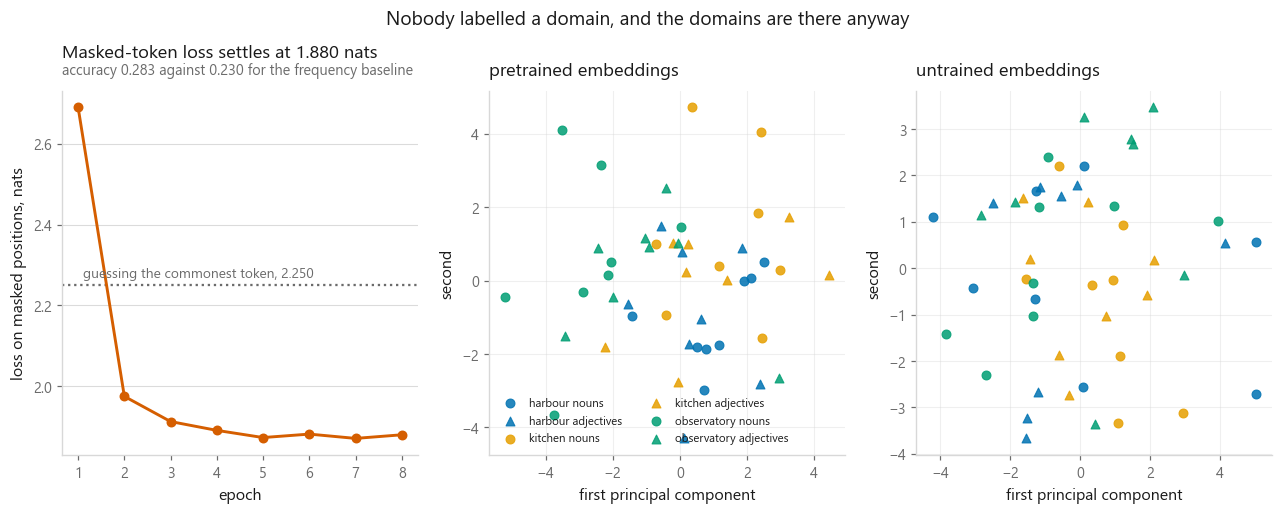

In [7]:
from sklearn.decomposition import PCA

torch.manual_seed(SEED + 99)
random_encoder = Encoder()

content_ids = [ID[w] for group in NOUNS for w in group] + \
              [ID[w] for group in ADJECTIVES for w in group]
content_domain = ([d for d in range(len(DOMAINS)) for _ in NOUNS[d]]
                  + [d for d in range(len(DOMAINS)) for _ in ADJECTIVES[d]])
content_kind = ["noun"] * sum(len(g) for g in NOUNS) + ["adjective"] * sum(len(g) for g in ADJECTIVES)

fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.3))

axes[0].axhline(loss_frequency, color=style.MUTED, ls=":", lw=1.5)
axes[0].annotate(f"guessing the commonest token, {loss_frequency:.3f}",
                 xy=(1, loss_frequency), xytext=(3, 5), textcoords="offset points",
                 fontsize=9, color=style.MUTED)
axes[0].plot(history["epoch"], history["masked-token loss"], color=style.HIGHLIGHT,
             marker=style.MARKERS[0], lw=1.9)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss on masked positions, nats")
axes[0].set_xticks(history["epoch"])
style.title(axes[0],
            f"Masked-token loss settles at {history['masked-token loss'].iloc[-1]:.3f} nats",
            f"accuracy {history['masked-token accuracy'].iloc[-1]:.3f} against "
            f"{guess_frequency:.3f} for the frequency baseline")

for ax, model, name in [(axes[1], encoder, "pretrained"), (axes[2], random_encoder, "untrained")]:
    table = model.embed.weight.detach().numpy()[content_ids]
    points = PCA(n_components=2, random_state=SEED).fit_transform(table)
    for d in range(len(DOMAINS)):
        for kind, marker in [("noun", "o"), ("adjective", "^")]:
            keep = [i for i in range(len(content_ids))
                    if content_domain[i] == d and content_kind[i] == kind]
            ax.scatter(points[keep, 0], points[keep, 1], s=34, marker=marker,
                       color=style.PALETTE[d], alpha=0.85,
                       label=f"{DOMAINS[d]} {kind}s" if ax is axes[1] else None)
    ax.set_xlabel("first principal component")
    ax.set_ylabel("second")
    ax.grid(True, axis="both", alpha=0.4)
    style.title(ax, f"{name} embeddings")

axes[1].legend(fontsize=7.5, ncol=2, loc="best")
fig.suptitle("Nobody labelled a domain, and the domains are there anyway",
             x=0.5, y=1.05, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-pretraining.png")

## 4. The downstream task, and three ways to attack it

Now a labelled problem the pretraining never saw. Given a sentence, say whether
the subject noun and the object noun belong to the same domain. A harbour crane
unloading a harbour barge is one class; a harbour crane unloading a kitchen
kettle is the other. Labels are balanced by construction, so chance is a half.

The task is deliberately **relational**. It does not turn on any single word.
Both nouns have to be recognised, mapped to their domains, and compared, and the
mapping from noun to domain is exactly what the pretraining had to learn in order
to predict masked adjectives. That is the transfer this notebook is trying to
measure.

Three ways to build a classifier, plus one classical control:

| Strategy | What moves during training |
|---|---|
| **Fine-tuning** | The pretrained encoder and a new head, both |
| **Feature extraction** | The head only. The encoder is frozen and used as a fixed function |
| **From scratch** | The same architecture from random weights, with no pretraining at all |
| **Bag of words** | Logistic regression on token counts, the [09-01](../01-text-preprocessing-and-tfidf/) baseline |

The head is a single linear layer on the mean of the token representations.

In [8]:
task_rng = np.random.default_rng(SEED + 7)
train_X, train_y, train_subject = make_corpus(4000, task_rng, balanced=True)
test_X, test_y, test_subject = make_corpus(3000, task_rng, balanced=True)
test_Xt, test_yt = torch.tensor(test_X), torch.tensor(test_y)

print(f"downstream pool {len(train_X):,} sentences, test set {len(test_X):,}")
print(f"share labelled same domain: train {train_y.mean():.4f}, test {test_y.mean():.4f}")
print("\ntwo examples:")
for i in [int(np.argmax(train_y)), int(np.argmin(train_y))]:
    print(f"  [{'same' if train_y[i] else 'different'}] " + " ".join(WORDS[t] for t in train_X[i]))


class Classifier(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(D_MODEL, 2)

    def forward(self, x):
        return self.head(self.encoder(x).mean(dim=1))


pretrained_state = copy.deepcopy(encoder.state_dict())
pretrained_mlm_head = copy.deepcopy(mlm.out.state_dict())


def train_downstream(strategy, n_labels, seed, steps=250, lr=3e-3, encoder_lr_ratio=1.0):
    """One downstream run. Returns test accuracy and the encoder it finished with."""
    torch.manual_seed(seed)
    body = Encoder()
    if strategy != "scratch":
        body.load_state_dict(pretrained_state)
    model = Classifier(body)

    if strategy == "frozen":
        for p in body.parameters():
            p.requires_grad = False
        groups = [{"params": model.head.parameters(), "lr": lr}]
    else:
        groups = [{"params": model.head.parameters(), "lr": lr},
                  {"params": body.parameters(), "lr": lr * encoder_lr_ratio}]
    opt = torch.optim.Adam(groups)

    # Nested subsets: the smallest training set is contained in every larger one,
    # so a curve moving is the model learning, not the sample changing.
    X = torch.tensor(train_X[:n_labels])
    y = torch.tensor(train_y[:n_labels])
    batch = min(32, n_labels)
    gen = torch.Generator().manual_seed(seed)

    model.train()
    for _ in range(steps):
        idx = torch.randint(0, n_labels, (batch,), generator=gen)
        opt.zero_grad()
        F.cross_entropy(model(X[idx]), y[idx]).backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        accuracy = float((model(test_Xt).argmax(1) == test_yt).float().mean())
    return accuracy, body

downstream pool 4,000 sentences, test set 3,000
share labelled same domain: train 0.4935, test 0.5143

two examples:
  [same] the tilted filter sweeps a calibrated lens beyond gallery
  [different] the polished filter focuses a scoured whisk beyond corridor


## 5. How much labelled data before the pretraining stops mattering

Six training-set sizes, three neural strategies, two seeds each, plus the bag of
words. Every run gets the same number of gradient steps, so the comparison is
about where the weights start rather than how long they trained.

In [9]:
from sklearn.linear_model import LogisticRegression

SIZES = [32, 64, 128, 256, 512, 1024]
STRATEGIES = ["finetune", "frozen", "scratch"]
SEEDS = [0, 1]


def bag_of_words(matrix):
    return np.stack([np.bincount(row, minlength=VOCAB) for row in matrix]).astype(float)


bow_train, bow_test = bag_of_words(train_X), bag_of_words(test_X)

sweep = []
started = time.perf_counter()
for n in SIZES:
    row = {"labelled sentences": n}
    for strategy in STRATEGIES:
        scores = [train_downstream(strategy, n, seed)[0] for seed in SEEDS]
        row[strategy] = float(np.mean(scores))
        row[f"{strategy} spread"] = float(np.ptp(scores))
    classical = LogisticRegression(max_iter=2000).fit(bow_train[:n], train_y[:n])
    row["bag of words"] = float(classical.score(bow_test, test_y))
    sweep.append(row)
    print(f"  n = {n:>5}  " + "  ".join(f"{s} {row[s]:.4f}" for s in STRATEGIES)
          + f"  bag of words {row['bag of words']:.4f}")

sweep = pd.DataFrame(sweep)
print(f"\n{len(SIZES) * len(STRATEGIES) * len(SEEDS)} neural runs in "
      f"{time.perf_counter() - started:.0f} s")
print(sweep[["labelled sentences", *STRATEGIES, "bag of words"]]
      .to_string(index=False, float_format="{:.4f}".format))

gap = sweep["finetune"] - sweep["scratch"]
seed_spread = float(sweep[[f"{s} spread" for s in STRATEGIES]].to_numpy().max())
print(f"\nfine-tuning minus from scratch, by size: "
      f"{', '.join(f'{v:+.4f}' for v in gap)}")
print(f"largest gap {gap.max():+.4f} at {sweep.loc[gap.idxmax(), 'labelled sentences']:.0f} "
      f"sentences, smallest {gap.min():+.4f} at "
      f"{sweep.loc[gap.idxmin(), 'labelled sentences']:.0f}")
print(f"largest seed spread across all runs: {seed_spread:.4f}")

# The seed spread is the bar every claim in this sweep has to clear, so put it
# next to the two comparisons the chapter is actually making.
methods = [*STRATEGIES, "bag of words"]
sweep["finetune minus frozen"] = sweep["finetune"] - sweep["frozen"]
sweep["finetune minus scratch"] = gap
decided = ((sweep["finetune minus frozen"].abs() > seed_spread)
           & (sweep["finetune minus scratch"].abs() > seed_spread))

print()
print(sweep[["labelled sentences", "finetune minus frozen", "finetune minus scratch"]]
      .assign(**{"both clear the seed spread": decided})
      .to_string(index=False, float_format="{:+.4f}".format))
print(f"\nsizes where fine-tuning's lead over both alternatives stays inside the "
      f"seed spread: {sweep.loc[~decided, 'labelled sentences'].tolist()}")
print(f"best of the four methods at {SIZES[0]} labels : {sweep.loc[0, methods].idxmax()}")
print(f"worst of the four at {SIZES[0]} labels        : {sweep.loc[0, methods].idxmin()}")

  n =    32  finetune 0.5102  frozen 0.5575  scratch 0.4832  bag of words 0.4967


  n =    64  finetune 0.5283  frozen 0.5025  scratch 0.5095  bag of words 0.5040


  n =   128  finetune 0.6435  frozen 0.5067  scratch 0.5348  bag of words 0.4973


  n =   256  finetune 0.8797  frozen 0.5063  scratch 0.6210  bag of words 0.4990


  n =   512  finetune 0.9665  frozen 0.5110  scratch 0.8108  bag of words 0.4950


  n =  1024  finetune 0.9903  frozen 0.4922  scratch 0.9395  bag of words 0.4817

36 neural runs in 57 s
 labelled sentences  finetune  frozen  scratch  bag of words
                 32    0.5102  0.5575   0.4832        0.4967
                 64    0.5283  0.5025   0.5095        0.5040
                128    0.6435  0.5067   0.5348        0.4973
                256    0.8797  0.5063   0.6210        0.4990
                512    0.9665  0.5110   0.8108        0.4950
               1024    0.9903  0.4922   0.9395        0.4817

fine-tuning minus from scratch, by size: +0.0270, +0.0188, +0.1087, +0.2587, +0.1557, +0.0508
largest gap +0.2587 at 256 sentences, smallest +0.0188 at 64
largest seed spread across all runs: 0.0567

 labelled sentences  finetune minus frozen  finetune minus scratch  both clear the seed spread
                 32                -0.0473                 +0.0270                       False
                 64                +0.0258                 +0.0188           

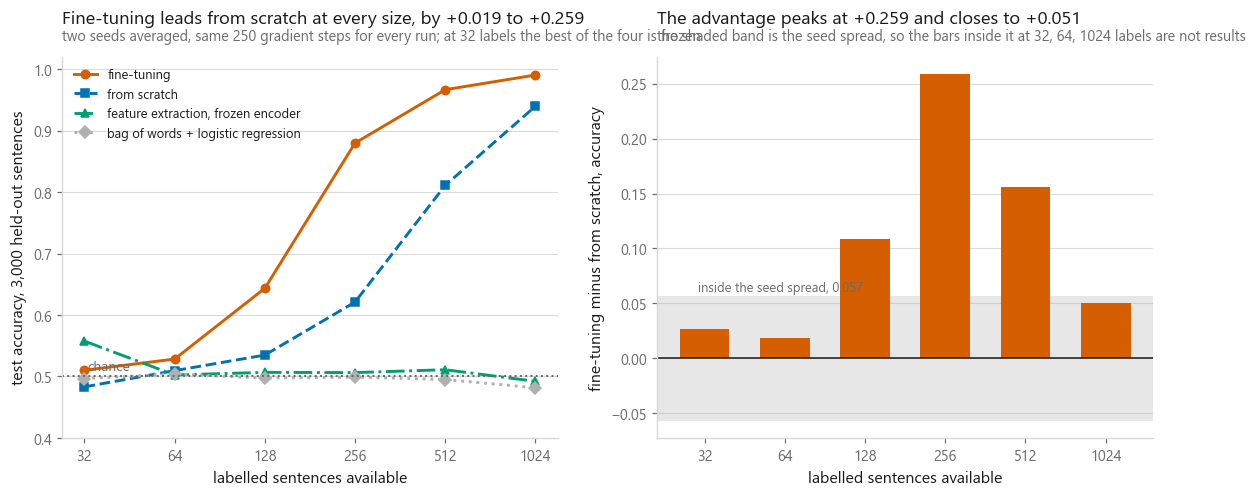

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.5))

series = [("finetune", "fine-tuning", style.HIGHLIGHT, 0),
          ("scratch", "from scratch", style.PALETTE[0], 1),
          ("frozen", "feature extraction, frozen encoder", style.PALETTE[2], 2),
          ("bag of words", "bag of words + logistic regression", style.NEUTRAL, 3)]
for column, label, colour, k in series:
    axes[0].plot(sweep["labelled sentences"], sweep[column], color=colour,
                 marker=style.MARKERS[k], ls=style.DASHES[k], lw=1.9, label=label)
axes[0].axhline(0.5, color=style.MUTED, ls=":", lw=1.3)
axes[0].annotate("chance", xy=(SIZES[0], 0.5), xytext=(2, 4), textcoords="offset points",
                 fontsize=9, color=style.MUTED)
axes[0].set_xscale("log", base=2)
axes[0].set_xticks(SIZES, [str(s) for s in SIZES])
axes[0].set_xlabel("labelled sentences available")
axes[0].set_ylabel("test accuracy, 3,000 held-out sentences")
axes[0].set_ylim(0.4, 1.02)
axes[0].legend(loc="upper left", fontsize=8.5)
style.title(axes[0],
            f"Fine-tuning leads from scratch at every size, by {gap.min():+.3f} to "
            f"{gap.max():+.3f}",
            f"two seeds averaged, same 250 gradient steps for every run; at "
            f"{SIZES[0]} labels the best of the four is "
            f"{sweep.loc[0, methods].idxmax()}")

axes[1].axhspan(-seed_spread, seed_spread, color=style.NEUTRAL, alpha=0.3, linewidth=0)
axes[1].bar(np.arange(len(SIZES)), gap, color=style.HIGHLIGHT, width=0.62)
axes[1].axhline(0.0, color=style.INK, lw=1.0)
axes[1].annotate(f"inside the seed spread, {seed_spread:.3f}", xy=(0, seed_spread),
                 xytext=(-4, 3), textcoords="offset points", fontsize=8.5,
                 color=style.MUTED)
axes[1].set_xticks(np.arange(len(SIZES)), [str(s) for s in SIZES])
axes[1].set_xlabel("labelled sentences available")
axes[1].set_ylabel("fine-tuning minus from scratch, accuracy")
style.title(axes[1],
            f"The advantage peaks at {gap.max():+.3f} and closes to {gap.iloc[-1]:+.3f}",
            f"the shaded band is the seed spread, so the bars inside it at "
            f"{', '.join(str(s) for s in sweep.loc[~decided, 'labelled sentences'])} "
            f"labels are not results")

style.save(fig, FIG / "fig-03-how-much-data.png")

### Reading the table against the image chapter

[08-05](../../08-computer-vision/05-transfer-learning/) ran this exact
comparison on Fashion-MNIST and found something people find hard to believe:
feature extraction lost to training from scratch at every single target size,
worst of all at the smallest one. The advice everybody repeats, freeze the
backbone when labels are scarce, did not survive the measurement.

The comparison here agrees from the second size onwards. The frozen encoder does
not improve as labels are added, from-scratch climbs steadily past it, and the
next section shows the reason is not that the frozen features are bad.

The smallest size is the row to read carefully, because it separates nothing.
There the frozen encoder is the best of the four and from-scratch is the worst,
which is the reverse of the ordering everywhere else, and the printed table says
fine-tuning's lead over both of them stays inside the seed spread. Four numbers
drawn from the same noise, arranged in an order that looks like a finding. It is
not evidence that freezing helps when labels are scarce, and it is not evidence
that it does not. At thirty-two labelled sentences the sweep has not started yet,
and the honest thing to do with a row like that is to say so rather than to name
a winner in it.

The other half of 08-05 replicated. Fine-tuning beat from-scratch at every size,
the margin peaked in the middle of the sweep, and by the largest size from-scratch
had caught up to within the seed spread again. Transfer buys you data, the amount
it buys shrinks as you get more of your own, and the printed column says the
advantage only clears the noise in the middle of the sweep.

## 6. Why the frozen encoder fails, diagnosed

There are two explanations for feature extraction sitting near chance, and they
call for opposite responses.

1. The pretrained features do not contain the domain information. If so, the
   pretraining was a waste and the fix is a better pretraining objective.
2. The features contain it, but a linear layer on the mean of them cannot
   express the comparison. If so, the pretraining is fine and the fix is a head
   with enough capacity, or unfreezing.

These are distinguishable. Probe the same frozen features with a logistic
regression on an easier question: which domain the **subject noun** belongs to.
That question is about a single word, not a relation, and if the features carry
domains at all it should be easy.

In [11]:
def pooled_features(model, tokens):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(tokens)).mean(dim=1).numpy()


probe_rows = []
for name, model in [("pretrained", encoder), ("untrained", random_encoder)]:
    train_feat = pooled_features(model, train_X)
    test_feat = pooled_features(model, test_X)
    for task, y_tr, y_te, chance in [
            ("subject domain (one word)", train_subject, test_subject, 1 / len(DOMAINS)),
            ("same domain (a relation)", train_y, test_y, 0.5)]:
        fitted = LogisticRegression(max_iter=3000).fit(train_feat, y_tr)
        probe_rows.append({"features": name, "probe": task,
                           "accuracy": float(fitted.score(test_feat, y_te)),
                           "chance": chance})

probes = pd.DataFrame(probe_rows)
print(probes.to_string(index=False, float_format="{:.4f}".format))

easy = probes[(probes["features"] == "pretrained") & (probes["probe"].str.startswith("subject"))]
hard = probes[(probes["features"] == "pretrained") & (probes["probe"].str.startswith("same"))]
print(f"\npretrained features, one-word question : {float(easy['accuracy'].iloc[0]):.4f}")
print(f"pretrained features, relational question: {float(hard['accuracy'].iloc[0]):.4f}")

  features                     probe  accuracy  chance
pretrained subject domain (one word)    0.9980  0.3333
pretrained  same domain (a relation)    0.5713  0.5000
 untrained subject domain (one word)    0.9373  0.3333
 untrained  same domain (a relation)    0.5090  0.5000

pretrained features, one-word question : 0.9980
pretrained features, relational question: 0.5713


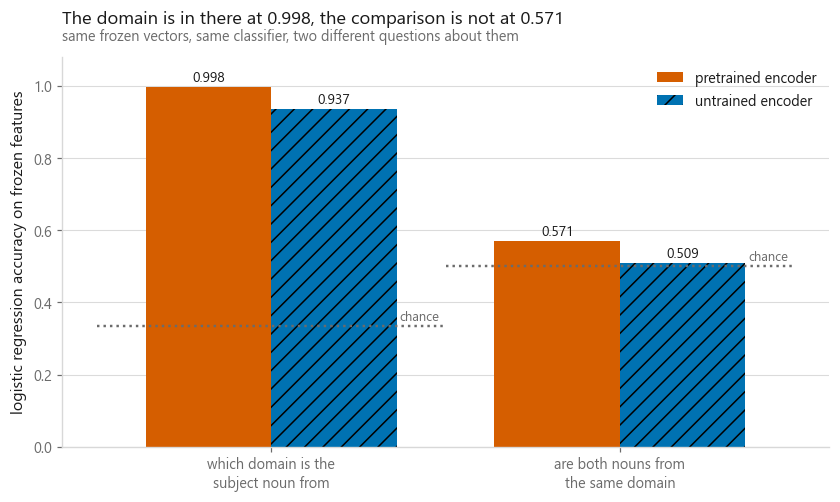

In [12]:
fig, ax = plt.subplots(figsize=(9.0, 4.6))

order = ["subject domain (one word)", "same domain (a relation)"]
width = 0.36
x = np.arange(len(order))
for k, name in enumerate(["pretrained", "untrained"]):
    values = [float(probes[(probes["features"] == name) & (probes["probe"] == p)]["accuracy"].iloc[0])
              for p in order]
    ax.bar(x + (k - 0.5) * width, values, width=width,
           color=[style.HIGHLIGHT, style.PALETTE[0]][k],
           hatch=["", "//"][k], label=f"{name} encoder")
    for xi, v in zip(x + (k - 0.5) * width, values):
        ax.text(xi, v + 0.015, f"{v:.3f}", ha="center", fontsize=9, color=style.INK)

for xi, p in zip(x, order):
    level = float(probes[probes["probe"] == p]["chance"].iloc[0])
    ax.plot([xi - 0.5, xi + 0.5], [level, level], color=style.MUTED, ls=":", lw=1.6)
    ax.annotate("chance", xy=(xi + 0.5, level), xytext=(-30, 4), textcoords="offset points",
                fontsize=8.5, color=style.MUTED)

ax.set_xticks(x, ["which domain is the\nsubject noun from", "are both nouns from\nthe same domain"])
ax.set_ylabel("logistic regression accuracy on frozen features")
ax.set_ylim(0, 1.08)
ax.legend(loc="upper right")
style.title(ax,
            f"The domain is in there at {float(easy['accuracy'].iloc[0]):.3f}, "
            f"the comparison is not at {float(hard['accuracy'].iloc[0]):.3f}",
            "same frozen vectors, same classifier, two different questions about them")
style.save(fig, FIG / "fig-04-probing-the-features.png")

That settles it. The domain of a noun is decodable from the frozen
representation by a linear model, and whether two nouns share a domain is not.
The pretraining did its job. Feature extraction failed because averaging token
vectors and applying one linear map cannot compute a comparison between two of
them, no matter how good the vectors are.

The untrained encoder is the part worth pausing on. It scores well above chance
on the one-word question, and the reason is that mean-pooling random embeddings
is a bag of words with random projections: which words are present survives the
pooling even when the vectors mean nothing. A frozen-feature baseline can look
respectable while carrying no learned knowledge at all, so a random-weights
control belongs next to it.

The practical lesson generalises past this toy. If your frozen features
underperform, ask whether the head can express the question before concluding
that the backbone is wrong.

## 7. What fine-tuning destroys

Fine-tuning moves the encoder's weights, and the encoder was carrying the
pretraining. The standard worry is **catastrophic forgetting**: the model gets
better at the new task by wrecking what it knew.

It is measurable. Put the original masked-language-model head back on the
fine-tuned encoder and score the pretraining objective again. That head has not
changed, so any loss is the features moving out from under it. This is the same
instrument [08-05](../../08-computer-vision/05-transfer-learning/) used on the
image side.

The usual defence is a **discriminative learning rate**: the new head starts from
noise and needs a full-sized step, while the encoder starts from something worth
keeping and should be nudged. The recipe most people quote is a tenth.

In [13]:
forgetting_head = nn.Linear(D_MODEL, VOCAB)
forgetting_head.load_state_dict(pretrained_mlm_head)
forgetting_head.eval()

score_X, _, _ = make_corpus(4000, corpus_rng)
score_t = torch.tensor(score_X)


def score_pretraining(body):
    """Masked-token loss and accuracy for `body` under the frozen original head."""
    body.eval()
    rng = np.random.default_rng(SEED + 5)          # same masks for every model scored
    total, count, correct = 0.0, 0, 0
    with torch.no_grad():
        for i in range(0, len(score_t), 500):
            batch = score_t[i:i + 500]
            masked, chosen = apply_mask(batch, rng)
            logits = forgetting_head(body(masked))[chosen]
            targets = batch[chosen]
            total += float(F.cross_entropy(logits, targets, reduction="sum"))
            correct += int((logits.argmax(-1) == targets).sum())
            count += len(targets)
    return total / count, correct / count


base_loss, base_accuracy = score_pretraining(encoder)
print(f"the pretrained checkpoint, before anything is fine-tuned")
print(f"  masked-token loss {base_loss:.4f} nats, accuracy {base_accuracy:.4f}\n")

SETTINGS = [("frozen encoder", "frozen", 0.0),
            ("encoder rate / 100", "finetune", 0.01),
            ("encoder rate / 10", "finetune", 0.1),
            ("encoder rate = head rate", "finetune", 1.0)]

rates = []
for label, strategy, ratio in SETTINGS:
    accuracy, body = train_downstream(strategy, 512, seed=0, encoder_lr_ratio=ratio)
    loss_after, accuracy_after = score_pretraining(body)
    rates.append({"setting": label, "target accuracy": accuracy,
                  "masked-token loss after": loss_after,
                  "masked-token accuracy after": accuracy_after,
                  "loss added": loss_after - base_loss})

rates = pd.DataFrame(rates)
print(rates.to_string(index=False, float_format="{:.4f}".format))

best_target = rates.loc[rates["target accuracy"].idxmax()]
print(f"\nbest target accuracy: {best_target['setting']}, "
      f"{best_target['target accuracy']:.4f}")
print(f"what it cost on the pretraining objective: "
      f"{best_target['loss added']:+.4f} nats, accuracy "
      f"{base_accuracy:.4f} -> {best_target['masked-token accuracy after']:.4f}")

the pretrained checkpoint, before anything is fine-tuned
  masked-token loss 1.8890 nats, accuracy 0.2760



                 setting  target accuracy  masked-token loss after  masked-token accuracy after  loss added
          frozen encoder           0.5030                   1.8890                       0.2760      0.0000
      encoder rate / 100           0.5153                   1.8878                       0.2750     -0.0013
       encoder rate / 10           0.8947                   1.9654                       0.2820      0.0764
encoder rate = head rate           0.9607                   5.4610                       0.0516      3.5720

best target accuracy: encoder rate = head rate, 0.9607
what it cost on the pretraining objective: +3.5720 nats, accuracy 0.2760 -> 0.0516


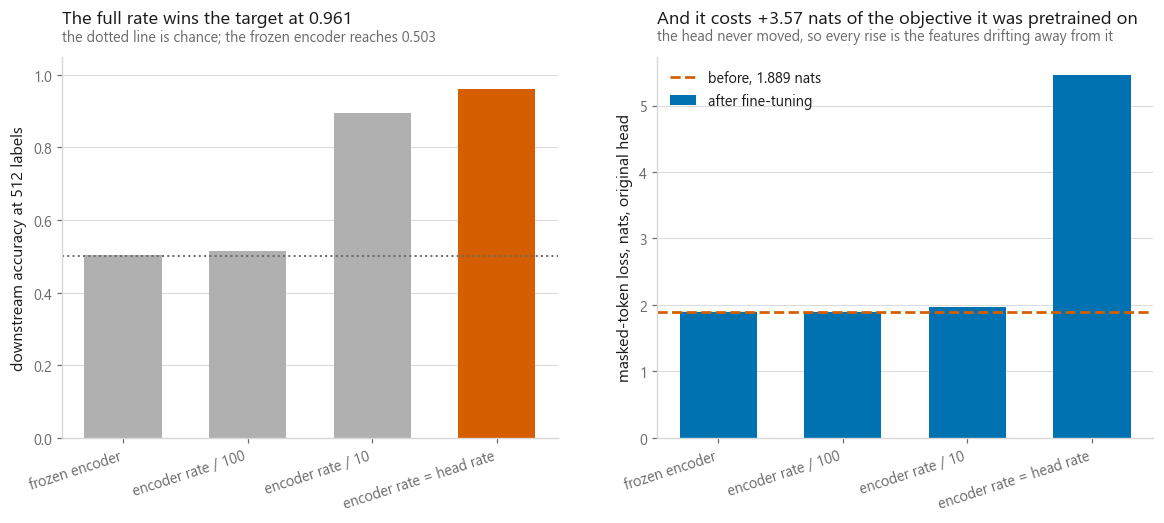

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.5))

labels = [row["setting"] for _, row in rates.iterrows()]
x = np.arange(len(labels))

axes[0].bar(x, rates["target accuracy"], color=style.spot(len(labels),
            int(rates["target accuracy"].idxmax())), width=0.62)
axes[0].axhline(0.5, color=style.MUTED, ls=":", lw=1.3)
axes[0].set_xticks(x, labels, rotation=18, ha="right")
axes[0].set_ylabel("downstream accuracy at 512 labels")
axes[0].set_ylim(0, 1.05)
style.title(axes[0],
            f"The full rate wins the target at {rates['target accuracy'].max():.3f}",
            f"the dotted line is chance; the frozen encoder reaches "
            f"{rates['target accuracy'].iloc[0]:.3f}")

axes[1].bar(x, rates["masked-token loss after"], color=style.PALETTE[0], width=0.62,
            label="after fine-tuning")
axes[1].axhline(base_loss, color=style.HIGHLIGHT, ls="--", lw=1.8,
                label=f"before, {base_loss:.3f} nats")
axes[1].set_xticks(x, labels, rotation=18, ha="right")
axes[1].set_ylabel("masked-token loss, nats, original head")
axes[1].legend(loc="upper left")
style.title(axes[1],
            f"And it costs {rates['loss added'].max():+.2f} nats of the objective it "
            f"was pretrained on",
            "the head never moved, so every rise is the features drifting away from it")

style.save(fig, FIG / "fig-05-forgetting.png")

I expected this table to reproduce 08-05, where the full learning rate destroyed
the source task **and** came out worse on the target, making the tenth-rate
recipe an easy sell. Half of that happened. The forgetting is here, larger than
on the image side, and the model that forgets the most is also the best model on
the task I actually asked for.

So the discriminative learning rate is not free accuracy. It is a trade, and
which side of it you want depends on a question about deployment rather than
about learning: is this checkpoint going to serve anything else. If the fine-tuned
model is the only artefact that ships, the forgetting column costs nothing and
the fastest-moving encoder is the right choice. If the same base has to serve
several tasks, or you plan to fine-tune it again next month, the tenth-rate row
is buying insurance, and the table says what the premium is.

The frozen row is the sanity check, landing exactly on the pretrained loss
because those weights never moved.

## 8. When it wins and when it loses

| | |
|---|---|
| **Pretraining wins** | When unlabelled data is plentiful, labels are scarce, and the structure the objective forces the model to learn overlaps with what the task needs |
| **Pretraining loses** | When you already have enough labels. The gap here closed as the labelled set grew, and 08-05 measured the same closing on images |
| **Feature extraction wins** | When the task is a simple readout of something already in the representation, and compute for a full fine-tune is not available |
| **Feature extraction loses** | When the task is relational or otherwise not linear in the pooled features. From the second labelled-set size onwards it sat near chance here while the features held the answer |
| **Watch out** | A random encoder plus mean pooling is a bag of words with extra steps, and it scores far above chance. Always run that control before claiming a frozen backbone is doing work |

## Cheat sheet

| | |
|---|---|
| **Masked language modelling** | Replace a fraction of tokens with `[MASK]`, predict them, take the loss at masked positions only |
| **Masking rate** | 15% is inherited from BERT. Too low wastes forward passes, too high removes the context needed to reconstruct |
| **Before you judge accuracy** | Compute the entropy of the slots. A slot holding one of eight equally likely nouns has a hard ceiling nothing can beat |
| **Scoring a baseline** | On exactly the rows the model was scored on. The same frequency rule averaged over all slots and over masked positions only gives two different numbers here, and the model beats one of them and loses to the other |
| **Fine-tuning** | Load the encoder, attach a fresh head, train both. Beat from-scratch at every labelled-set size measured here, though only outside the seed spread in the middle of the sweep. At the smallest size the frozen encoder scored highest of the four, inside the noise |
| **Feature extraction** | Freeze the encoder, train the head. Cheap, and it can only express what one linear map of the pooled features can express |
| **From scratch** | The control that decides whether pretraining bought anything. Run it every time |
| **Discriminative rates** | Encoder at a fraction of the head's rate. Here the full rate scored best on the target and forgot the most |
| **Measuring forgetting** | Put the original pretraining head back on the fine-tuned body. The head is unchanged, so any loss is the features moving |
| **Sanity control** | A random encoder with the same pooling. If your frozen features cannot beat it, they are not features |

## What to remember

1. Pretraining converts unlabelled text into supervision by hiding part of the
   input. There is no trick beyond that, and the whole method fits in about
   thirty lines.
2. Compute the entropy of what you are asking the model to predict before
   judging its accuracy, and score your baseline on exactly the positions the
   model was scored on. This notebook prints the same frequency rule twice, over
   all slots and over masked positions only, and the model beats one and loses to
   the other. Most of the loss in a language model is irreducible either way.
3. The domains in this language were never labelled and the embeddings clustered
   by domain anyway, because predicting a masked adjective requires knowing which
   nouns it goes with.
4. Fine-tuning beat from-scratch at every labelled-set size here, but the margin
   only cleared the seed spread in the middle of the sweep: at the two smallest
   sizes it was inside the noise, and at the largest size from-scratch had closed
   back inside it. That shape, a peak in the middle and a narrowing at the top,
   is what 08-05 measured on images.
5. The smallest labelled set separated nothing. The frozen encoder came out
   highest there and from-scratch lowest, the reverse of every other row, and no
   gap was worth the seed spread. A sweep's first point is usually a coin toss
   with a legend attached.
6. Feature extraction sat near chance from the second size on, and the probe
   showed the reason was the head rather than the features. Diagnose before you
   replace the backbone.
7. A random encoder with mean pooling scores far above chance on a single-word
   question. Without that control, a frozen baseline flatters itself.
8. Fine-tuning at the full learning rate cost the most of the pretraining
   objective and still won the downstream task. Forgetting is a price, not
   automatically a mistake, and whether to pay it depends on what else the
   checkpoint has to do.
9. Every claim above rests on one small synthetic language and two seeds, and the
   printed seed spread is wide enough to swallow three rows of the sweep. The
   mechanisms transfer, the exact margins do not.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [09-09 Time series forecasting](../09-time-series-forecasting/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#Transformers` `#FineTuning` `#TransferLearning` `#NLP`
`#PyTorch` `#SelfSupervised` `#MachineLearning` `#MLTutorial` `#Python`